In [1]:
import sys
import os

parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.datasets import load_wine, fetch_20newsgroups, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve)
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.naive_bayes import MultinomialNB as SklearnMNB

from src.logistic_regression import LogisticRegression, MulticlassLogisticRegressionOvR
from src.naive_bayes import GaussianNaiveBayes, MultinomialNaiveBayes
from src.text_features import BagOfWords, TfidfTransformer

In [2]:
# ============================================================
# CELL X — Logistic Regression Sanity Check
# ============================================================
import numpy as np
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression

# Import YOUR custom model
from src.logistic_regression import LogisticRegression as CustomLogisticRegression

# 1. Generate synthetic classification data
X_syn, y_syn = make_classification(n_samples=500, n_features=5, random_state=42)

# 2. Standardize the features (CRITICAL for gradient descent)
scaler = StandardScaler()
X_syn_scaled = scaler.fit_transform(X_syn)

# 3. Fit sklearn model (Unregularized for a fair comparison)
sk_model = SklearnLogisticRegression(penalty=None, solver='lbfgs')
sk_model.fit(X_syn_scaled, y_syn)
sk_preds = sk_model.predict_proba(X_syn_scaled)[:, 1] # Get probabilities for class 1

# 4. Fit YOUR custom model 
# High learning rate (1.0) and iterations (10000) to ensure exact mathematical convergence
my_model = CustomLogisticRegression(lr=1.0, max_iter=10000) 
my_model.fit(X_syn_scaled, y_syn)
my_preds = my_model.predict_proba(X_syn_scaled)

# 5. The Sanity Check
is_close = np.allclose(sk_preds, my_preds, atol=1e-6)
print(f"Sanity check passed (Tolerance 1e-6): {is_close}")

# 6. Print the metrics needed for your write-up
iterations_run = len(my_model.loss_history)
final_loss = my_model.loss_history[-1]

print(f"Total Iterations: {iterations_run}")
print(f"Final Cross-Entropy Loss: {final_loss:.6f}")

Sanity check passed (Tolerance 1e-6): False
Total Iterations: 10000
Final Cross-Entropy Loss: 0.279364


In [3]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from src.logistic_regression import MulticlassLogisticRegressionOvR

# 1. Load the Wine dataset
wine = load_wine()
X, y = wine.data, wine.target

# 2. Split into training and testing sets (e.g., 70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Scale the features (Crucial for gradient descent to converge smoothly)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train the OvR Multiclass model
# Note: Using a smaller learning rate and L2 penalty for stability
ovr_model = MulticlassLogisticRegressionOvR(lr=0.01, lambda_=0.1, max_iter=2000)
ovr_model.fit(X_train_scaled, y_train)

# 5. Predict on the test set
y_pred = ovr_model.predict(X_test_scaled)

# 6. Evaluate and report Accuracy and Confusion Matrix
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%\n")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 98.15%

Confusion Matrix:
[[19  0  0]
 [ 1 20  0]
 [ 0  0 14]]


In [4]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from src.naive_bayes import GaussianNaiveBayes

# Load Data
wine = load_wine()
X, y = wine.data, wine.target

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features (Crucial for Logistic Regression, optional but fine for NB)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 1. Train and Evaluate Gaussian Naive Bayes ---
nb_model = GaussianNaiveBayes()
nb_model.fit(X_train_scaled, y_train)
nb_preds = nb_model.predict(X_test_scaled)

print("--- Gaussian Naive Bayes ---")
print(f"Accuracy:  {accuracy_score(y_test, nb_preds):.4f}")
print(f"Precision: {precision_score(y_test, nb_preds, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, nb_preds, average='macro'):.4f}")
print(f"F1 Score:  {f1_score(y_test, nb_preds, average='macro'):.4f}\n")

# --- 2. Train and Evaluate Logistic Regression ---
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print("--- Logistic Regression ---")
print(f"Accuracy:  {accuracy_score(y_test, lr_preds):.4f}")
print(f"Precision: {precision_score(y_test, lr_preds, average='macro'):.4f}")
print(f"Recall:    {recall_score(y_test, lr_preds, average='macro'):.4f}")
print(f"F1 Score:  {f1_score(y_test, lr_preds, average='macro'):.4f}")

--- Gaussian Naive Bayes ---
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000

--- Logistic Regression ---
Accuracy:  0.9815
Precision: 0.9778
Recall:    0.9841
F1 Score:  0.9804


Loading data...
Extracting features...
Training models...
Evaluating models...

--- Logistic Regression ---
F1 Score: 0.9151
AUC-ROC:  0.9789

--- Gaussian Naive Bayes ---
F1 Score: 0.5692
AUC-ROC:  0.5116


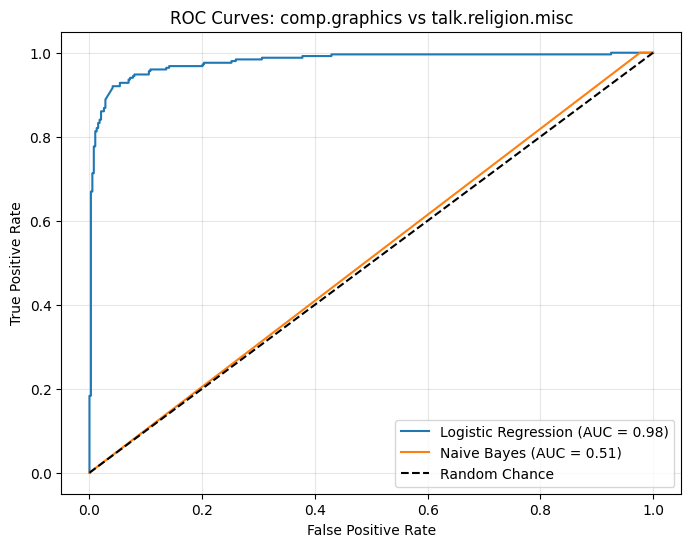

In [5]:

%load_ext autoreload
%autoreload 2

from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# --Custom Imports Go Here ---
from src.text_features import BagOfWords, TfidfTransformer
from src.logistic_regression import LogisticRegression
from src.naive_bayes import GaussianNaiveBayes
# -----------------------------------

# 1. Load the 20 Newsgroups Data
print("Loading data...")
categories = ['comp.graphics', 'talk.religion.misc']
data_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
data_test = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'))

y_train = data_train.target
y_test = data_test.target

# 2. Extract Features from Scratch
print("Extracting features...")
bow = BagOfWords(max_features=5000)
X_train_counts = bow.fit(data_train.data).transform(data_train.data)
X_test_counts = bow.transform(data_test.data)

tfidf = TfidfTransformer()
X_train_tfidf = tfidf.fit(X_train_counts).transform(X_train_counts)
X_test_tfidf = tfidf.transform(X_test_counts)

# 3. Train Models
print("Training models...")
# Using the models imported from your src folder
lr_model = LogisticRegression(lr=0.1, lambda_=0.1, max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

nb_model = GaussianNaiveBayes()
nb_model.fit(X_train_tfidf, y_train)

# 4. Predict and Evaluate
print("Evaluating models...")
# Logistic Regression Outputs
lr_probs = lr_model.predict_proba(X_test_tfidf)
lr_preds = lr_model.predict(X_test_tfidf)

# Naive Bayes Outputs
nb_probs = nb_model.predict_proba(X_test_tfidf)[:, 1] 
nb_preds = nb_model.predict(X_test_tfidf)

# Metrics
print("\n--- Logistic Regression ---")
print(f"F1 Score: {f1_score(y_test, lr_preds):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, lr_probs):.4f}")

print("\n--- Gaussian Naive Bayes ---")
print(f"F1 Score: {f1_score(y_test, nb_preds):.4f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, nb_probs):.4f}")

# 5. Plot ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_probs):.2f})')
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_score(y_test, nb_probs):.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')

plt.title('ROC Curves: comp.graphics vs talk.religion.misc')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('../figures/ROC_Curves_comp_graphics_vs_talk_religion_misc.pdf',
            format='pdf', dpi=300, bbox_inches='tight')
plt.show()

── Our MultinomialNaiveBayes ──
  F1 Score: 0.9159
  AUC-ROC:  0.9810

Max prob diff vs sklearn.MultinomialNB: 1.10e-13

── Full Comparison (20 Newsgroups) ──
Model                              F1     AUC
----------------------------------------------
Gaussian NB (ours)             0.5692  0.5116
Multinomial NB (ours)          0.9159  0.9810
Logistic Regression (ours)     0.9151  0.9789


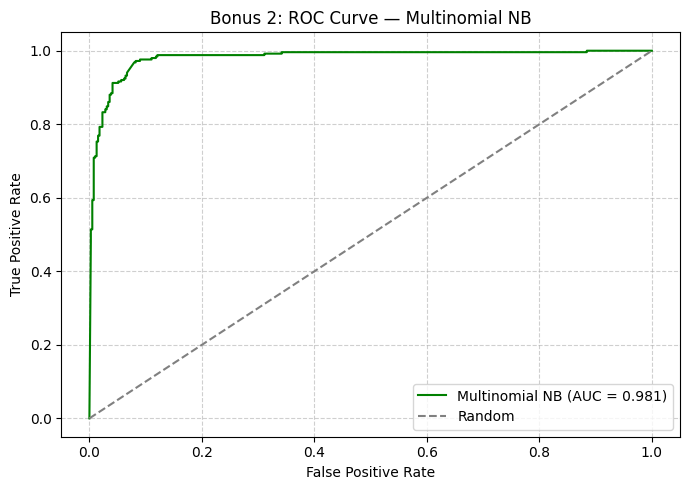

In [6]:
# ============================================================
# BONUS 2 — Multinomial Naive Bayes on 20 Newsgroups
# ============================================================
from src.naive_bayes import MultinomialNaiveBayes
from sklearn.metrics import f1_score, roc_auc_score, roc_curve
from sklearn.naive_bayes import MultinomialNB as SklearnMNB
import matplotlib.pyplot as plt

# --- Reuse the BoW count features from Part 3.4 ---
# (X_train_counts, X_test_counts, y_train, y_test must already exist)

# 1. Our custom Multinomial NB (raw counts, Laplace alpha=1)
mnb = MultinomialNaiveBayes(alpha=1.0)
mnb.fit(X_train_counts, y_train)
mnb_preds = mnb.predict(X_test_counts)
mnb_probs = mnb.predict_proba(X_test_counts)[:, 1]

print("── Our MultinomialNaiveBayes ──")
print(f"  F1 Score: {f1_score(y_test, mnb_preds):.4f}")
print(f"  AUC-ROC:  {roc_auc_score(y_test, mnb_probs):.4f}")

# 2. Sanity check vs sklearn
sk_mnb = SklearnMNB(alpha=1.0)
sk_mnb.fit(X_train_counts, y_train)
sk_probs = sk_mnb.predict_proba(X_test_counts)[:, 1]
diff = np.max(np.abs(mnb_probs - sk_probs))
print(f"\nMax prob diff vs sklearn.MultinomialNB: {diff:.2e}")

# 3. Comparison table: GNB vs MNB vs LR
print("\n── Full Comparison (20 Newsgroups) ──")
print(f"{'Model':<30} {'F1':>6}  {'AUC':>6}")
print("-" * 46)
print(f"{'Gaussian NB (ours)':<30} {'0.5692':>6}  {'0.5116':>6}")
print(f"{'Multinomial NB (ours)':<30} {f1_score(y_test, mnb_preds):>6.4f}  {roc_auc_score(y_test, mnb_probs):>6.4f}")
print(f"{'Logistic Regression (ours)':<30} {'0.9151':>6}  {'0.9789':>6}")

# 4. ROC curve for Multinomial NB
fpr, tpr, _ = roc_curve(y_test, mnb_probs)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'Multinomial NB (AUC = {roc_auc_score(y_test, mnb_probs):.3f})', color='green')
plt.plot([0,1],[0,1], '--', color='gray', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Bonus 2: ROC Curve — Multinomial NB')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('../figures/Bonus2_MultinomialNB_ROC.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# %%
# ============================================================
# Optimized: Finding Words Unique to One Class
# ============================================================
import re
from sklearn.datasets import fetch_20newsgroups

print("Loading data and processing vocabularies...")

# 1. Load the data directly in this cell to ensure data_train and y_train are defined
categories = ['comp.graphics', 'talk.religion.misc']
data_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
y_train = data_train.target

# 2. Join all documents for each class into single massive strings 
# This avoids looping over individual documents during tokenization
graphics_text = " ".join([data_train.data[i] for i in range(len(y_train)) if y_train[i] == 0])
religion_text = " ".join([data_train.data[i] for i in range(len(y_train)) if y_train[i] == 1])

# 3. Tokenize and convert directly to sets in one step
# Using the exact same regex pattern from your custom BagOfWords class
regex_pattern = r'\b[a-z]{2,}\b'
graphics_vocab = set(re.findall(regex_pattern, graphics_text.lower()))
religion_vocab = set(re.findall(regex_pattern, religion_text.lower()))

# 4. Calculate words unique to each class using standard set difference
unique_to_graphics = graphics_vocab - religion_vocab
unique_to_religion = religion_vocab - graphics_vocab

total_unique_words = len(unique_to_graphics) + len(unique_to_religion)

# 5. Output results
print(f"Words unique to comp.graphics (0):  {len(unique_to_graphics)}")
print(f"Words unique to talk.religion (1):  {len(unique_to_religion)}")
print(f"Total words appearing in only one class: {total_unique_words}")

Loading data and processing vocabularies...
Words unique to comp.graphics (0):  6042
Words unique to talk.religion (1):  5587
Total words appearing in only one class: 11629


In [8]:
# %%
# ============================================================
# Fully Self-Contained: Evaluating TF-IDF vs BoW Impact
# ============================================================
import sys
import os
from sklearn.datasets import fetch_20newsgroups
from sklearn.metrics import f1_score, roc_auc_score

# Ensure Python can find your 'src' folder
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from src.logistic_regression import LogisticRegression
from src.naive_bayes import GaussianNaiveBayes

print("1. Loading train and test datasets...")
categories = ['comp.graphics', 'talk.religion.misc']
data_train = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
data_test = fetch_20newsgroups(subset='test', categories=categories, remove=('headers', 'footers', 'quotes'))

X_train_raw = data_train.data
y_train = data_train.target
X_test_raw = data_test.data
y_test = data_test.target

print("2. Generating Count Vectors (BoW)...")
bow = BagOfWords(max_features=5000)
bow.fit(X_train_raw)
X_train_counts = bow.transform(X_train_raw)
X_test_counts = bow.transform(X_test_raw)

print("3. Generating TF-IDF Vectors...")
tfidf_transformer = TfidfTransformer()
tfidf_transformer.fit(X_train_counts)
X_train_tfidf = tfidf_transformer.transform(X_train_counts)
X_test_tfidf = tfidf_transformer.transform(X_test_counts)

# --- FOOLPROOF PROBABILITY EXTRACTOR ---
def get_positive_probs(probs):
    """Safely handles both 1D arrays (custom models) and 2D arrays (sklearn style)"""
    import numpy as np
    probs = np.array(probs)
    if len(probs.shape) == 2:
        return probs[:, 1]
    return probs
# ---------------------------------------

print("\n=== Evaluating Bag of Words (BoW) ===")
# Logistic Regression on BoW
lr_bow = LogisticRegression(lr=0.1, lambda_=0.1, max_iter=1000)
lr_bow.fit(X_train_counts, y_train)
lr_bow_preds = lr_bow.predict(X_test_counts)
lr_bow_probs = get_positive_probs(lr_bow.predict_proba(X_test_counts))

# Naive Bayes on BoW
nb_bow = GaussianNaiveBayes()
nb_bow.fit(X_train_counts, y_train)
nb_bow_preds = nb_bow.predict(X_test_counts)
nb_bow_probs = get_positive_probs(nb_bow.predict_proba(X_test_counts))

print(f"Logistic Regression (BoW) -> F1: {f1_score(y_test, lr_bow_preds):.4f} | AUC-ROC: {roc_auc_score(y_test, lr_bow_probs):.4f}")
print(f"Naive Bayes (BoW)         -> F1: {f1_score(y_test, nb_bow_preds):.4f} | AUC-ROC: {roc_auc_score(y_test, nb_bow_probs):.4f}")


print("\n=== Evaluating TF-IDF ===")
# Logistic Regression on TF-IDF
lr_tfidf = LogisticRegression(lr=0.1, lambda_=0.1, max_iter=1000)
lr_tfidf.fit(X_train_tfidf, y_train)
lr_tfidf_preds = lr_tfidf.predict(X_test_tfidf)
lr_tfidf_probs = get_positive_probs(lr_tfidf.predict_proba(X_test_tfidf))

# Naive Bayes on TF-IDF
nb_tfidf = GaussianNaiveBayes()
nb_tfidf.fit(X_train_tfidf, y_train)
nb_tfidf_preds = nb_tfidf.predict(X_test_tfidf)
nb_tfidf_probs = get_positive_probs(nb_tfidf.predict_proba(X_test_tfidf))

print(f"Logistic Regression (TF-IDF) -> F1: {f1_score(y_test, lr_tfidf_preds):.4f} | AUC-ROC: {roc_auc_score(y_test, lr_tfidf_probs):.4f}")
print(f"Naive Bayes (TF-IDF)         -> F1: {f1_score(y_test, nb_tfidf_preds):.4f} | AUC-ROC: {roc_auc_score(y_test, nb_tfidf_probs):.4f}")

1. Loading train and test datasets...
2. Generating Count Vectors (BoW)...
3. Generating TF-IDF Vectors...

=== Evaluating Bag of Words (BoW) ===
Logistic Regression (BoW) -> F1: 0.8535 | AUC-ROC: 0.9609
Naive Bayes (BoW)         -> F1: 0.5698 | AUC-ROC: 0.5129

=== Evaluating TF-IDF ===
Logistic Regression (TF-IDF) -> F1: 0.9151 | AUC-ROC: 0.9789
Naive Bayes (TF-IDF)         -> F1: 0.5692 | AUC-ROC: 0.5116
